In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/faridhasan007/fknews/fake_and_real_news.csv
/kaggle/input/datasets/faridhasan007/fake-news/fake_and_real_news.csv


In [2]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42


In [3]:
DATA_PATH = "/kaggle/input/datasets/faridhasan007/fknews/fake_and_real_news.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())


Dataset shape: (9900, 2)

Data types:
Text     object
label    object
dtype: object

First 5 rows:


,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

print("\nNumber of duplicate articles:", df["Text"].duplicated().sum())

print("\nUnique labels:")
print(df["label"].value_counts())


Missing values:
Text     0
label    0
dtype: int64

Number of duplicate rows: 35

Number of duplicate articles: 35

Unique labels:
label
Fake    5000
Real    4900
Name: count, dtype: int64


In [5]:
required_columns = {"Text", "label"}

if not required_columns.issubset(df.columns):
    raise ValueError(
        f"Dataset must contain columns {required_columns}, "
        f"but found {set(df.columns)}"
    )


In [6]:
df = df.dropna(subset=["Text", "label"]).copy()

df["Text"] = df["Text"].astype(str).str.strip()
df["label"] = df["label"].astype(str).str.strip()

# Remove empty articles
df = df[df["Text"].str.len() > 0].copy()

# Remove exact duplicate articles
df = df.drop_duplicates(subset=["Text"]).reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print("\nLabels:")
print(df["label"].value_counts())


Shape after cleaning: (9864, 2)

Labels:
label
Fake    5000
Real    4864
Name: count, dtype: int64


In [7]:
X = df["Text"]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClasses:", sorted(y.unique()))


X shape: (9864,)
y shape: (9864,)

Classes: ['Fake', 'Real']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))


Training samples: 7891
Test samples: 1973

Training label distribution:
label
Fake    0.506907
Real    0.493093
Name: proportion, dtype: float64

Test label distribution:
label
Fake    0.506842
Real    0.493158
Name: proportion, dtype: float64


In [26]:
count_nb = Pipeline([
    ("vectorizer", CountVectorizer(
        lowercase=True,
        stop_words="english"
    )),
    ("classifier", MultinomialNB())
])


In [27]:
tfidf_nb = Pipeline([
    ("vectorizer", TfidfVectorizer(
        lowercase=True,
        stop_words="english"
    )),
    ("classifier", MultinomialNB())
])


In [28]:
tfidf_lr = Pipeline([
    ("vectorizer", TfidfVectorizer(
        lowercase=True,
        stop_words="english"
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])


In [29]:
models = {
    "CountVectorizer + MultinomialNB": count_nb,
    "TfidfVectorizer + MultinomialNB": tfidf_nb,
    "TfidfVectorizer + LogisticRegression": tfidf_lr
}


In [30]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


In [31]:
scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro"
}


In [32]:
results = []

for name, pipeline in models.items():

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    results.append({
        "Model": name,

        "Mean CV Accuracy":
            cv_results["test_accuracy"].mean(),

        "Std CV Accuracy":
            cv_results["test_accuracy"].std(),

        "Mean CV Macro F1":
            cv_results["test_macro_f1"].mean(),

        "Std CV Macro F1":
            cv_results["test_macro_f1"].std()
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Mean CV Macro F1",
    ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))


,Model,Mean CV Accuracy,Std CV Accuracy,Mean CV Macro F1,Std CV Macro F1
0,TfidfVectorizer + LogisticRegression,0.9878,0.0040,0.9878,0.0040
1,CountVectorizer + MultinomialNB,0.9702,0.0038,0.9702,0.0038
2,TfidfVectorizer + MultinomialNB,0.9582,0.0056,0.9582,0.0056


In [33]:
best_model_name = comparison_df.iloc[0]["Model"]

best_pipeline = models[best_model_name]

print("Selected model:", best_model_name)


Selected model: TfidfVectorizer + LogisticRegression


In [34]:
best_pipeline.fit(X_train, y_train)

print("Final pipeline fitted successfully.")


Final pipeline fitted successfully.


In [35]:
y_pred = best_pipeline.predict(X_test)


In [36]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.9899


In [37]:
precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Test Precision (Macro): {precision:.4f}")
print(f"Test Recall (Macro):    {recall:.4f}")
print(f"Test F1 (Macro):        {f1:.4f}")


Test Precision (Macro): 0.9899
Test Recall (Macro):    0.9898
Test F1 (Macro):        0.9899


In [38]:
precision = precision_score(
    y_test,
    y_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(f"Test Precision (Macro): {precision:.4f}")
print(f"Test Recall (Macro):    {recall:.4f}")
print(f"Test F1 (Macro):        {f1:.4f}")


Test Precision (Macro): 0.9899
Test Recall (Macro):    0.9898
Test F1 (Macro):        0.9899


In [39]:
# ValueError: pos_label=1 is not a valid label.
# It should be one of ['Fake', 'Real']


In [40]:
labels = ["Fake", "Real"]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

print("Confusion Matrix")
print(pd.DataFrame(
    cm,
    index=["Actual Fake", "Actual Real"],
    columns=["Predicted Fake", "Predicted Real"]
))


Confusion Matrix
             Predicted Fake  Predicted Real
Actual Fake             992               8
Actual Real              12             961


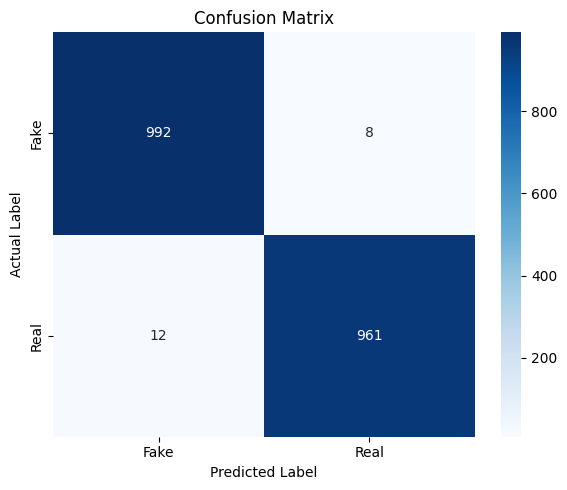

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [42]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        labels=labels,
        target_names=labels,
        digits=4
    )
)


Classification Report:
              precision    recall  f1-score   support

        Fake     0.9880    0.9920    0.9900      1000
        Real     0.9917    0.9877    0.9897       973

    accuracy                         0.9899      1973
   macro avg     0.9899    0.9898    0.9899      1973
weighted avg     0.9899    0.9899    0.9899      1973



In [45]:
test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(test_results.round(4))


,Metric,Score
0,Accuracy,0.9899
1,Precision,0.9899
2,Recall,0.9898
3,F1 Score,0.9899


In [46]:
predictions_df = pd.DataFrame({
    "Text": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred
})

predictions_df["Correct"] = (
    predictions_df["Actual"] == predictions_df["Predicted"]
)


In [47]:
correct_predictions = predictions_df[
    predictions_df["Correct"]
]

display(
    correct_predictions[
        ["Text", "Actual", "Predicted"]
    ].head(5)
)


,Text,Actual,Predicted
0,House overwhelmingly backs NATO mutual defense...,Real,Real
1,WATCH: Don Lemon CRUSHES Trump Supporter For C...,Fake,Fake
2,Adam Schiff SAVAGES Republicans For Canceling ...,Fake,Fake
3,Ruth Bader Ginsburg Makes America A Promise An...,Fake,Fake
4,'Fist bumps' at hedge funds over Trump's tax p...,Real,Real


In [48]:
incorrect_predictions = predictions_df[
    ~predictions_df["Correct"]
]

print("Number of incorrect predictions:",
      len(incorrect_predictions))

display(
    incorrect_predictions[
        ["Text", "Actual", "Predicted"]
    ].head(10)
)


Number of incorrect predictions: 20


,Text,Actual,Predicted
17,Factbox: First 100 days of Trump on Twitter (R...,Real,Fake
65,What's a 'dotard' anyway? Kim's insult to Trum...,Real,Fake
202,Trump reelection campaign raised $10 million i...,Real,Fake
364,BOMBSHELL: Senate Intel Committee Hearing Reve...,Fake,Real
675,Trump Doesn’t Want You To Know About This Stud...,Fake,Real
774,It’s Happening: FBI Carries Out Predawn Raid O...,Fake,Real
779,Fights erupt at pro-Trump rally on California ...,Real,Fake
797,Lawmakers Want Answers About Jared Kushner’s H...,Fake,Real
837,Yes he can: 'Clever boy' Obama returns to Indo...,Real,Fake
846,Trump Administration Is Already Talking About ...,Fake,Real


In [49]:
os.makedirs("models", exist_ok=True)


In [50]:
MODEL_PATH = "models/best_model.pkl"

joblib.dump(
    best_pipeline,
    MODEL_PATH
)

print(f"Saved model to: {MODEL_PATH}")


Saved model to: models/best_model.pkl


In [51]:
loaded_model = joblib.load("models/best_model.pkl")

sample_text = [
    "The government announced a new policy today after a formal meeting."
]

prediction = loaded_model.predict(sample_text)

print("Prediction:", prediction[0])


Prediction: Real


In [52]:
sample_articles = [
    "The government announced a new policy today after a formal meeting.",
    "Scientists released the results of a new study following several years of research."
]

predictions = loaded_model.predict(sample_articles)

for text, prediction in zip(sample_articles, predictions):
    print("Prediction:", prediction)
    print("Text:", text)
    print()


Prediction: Real
Text: The government announced a new policy today after a formal meeting.

Prediction: Fake
Text: Scientists released the results of a new study following several years of research.



Gradio

In [53]:
import joblib
import gradio as gr
import pandas as pd

# ============================================================
# 1. Load the trained pipeline
# ============================================================

MODEL_PATH = "models/best_model.pkl"

model = joblib.load(MODEL_PATH)

print("Model loaded successfully.")
print("Pipeline:", model)


# ============================================================
# 2. Prediction function
# ============================================================

def predict_news(text):
    """
    Accept raw news article text and return:
    - predicted label
    - probability/confidence for Fake
    - probability/confidence for Real
    """

    # Handle empty input
    if text is None or not text.strip():
        return "Please enter a news article.", {
            "Fake": 0.0,
            "Real": 0.0
        }

    # The saved pipeline performs vectorization internally
    prediction = model.predict([text])[0]

    # Get probabilities if the classifier supports predict_proba
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba([text])[0]
        classes = model.classes_

        prob_dict = dict(zip(classes, probabilities))

        fake_prob = prob_dict.get("Fake", 0.0)
        real_prob = prob_dict.get("Real", 0.0)

    else:
        # Fallback if the classifier does not support probabilities
        fake_prob = 1.0 if prediction == "Fake" else 0.0
        real_prob = 1.0 if prediction == "Real" else 0.0

    result = f"Predicted label: {prediction}"

    confidence = {
        "Fake": float(fake_prob),
        "Real": float(real_prob)
    }

    return result, confidence


# ============================================================
# 3. Gradio interface
# ============================================================

examples = [
    [
        """Scientists at the national research institute announced the
        results of a five-year study after reviewing thousands of samples.
        The researchers said the findings will be published in a peer-reviewed
        journal next month."""
    ],
    [
        """BREAKING: Officials secretly confirmed that drinking a special
        mixture of household ingredients can make people completely immune
        to every known disease. Experts supposedly do not want the public
        to know about this discovery."""
    ],
    [
        """The central bank announced its latest interest-rate decision
        following a scheduled policy meeting. Officials said the decision
        was based on inflation, employment and broader economic conditions."""
    ]
]


demo = gr.Interface(
    fn=predict_news,

    inputs=gr.Textbox(
        lines=15,
        placeholder="Paste a news article here...",
        label="News Article"
    ),

    outputs=[
        gr.Textbox(
            label="Prediction"
        ),

        gr.Label(
            num_top_classes=2,
            label="Class Confidence"
        )
    ],

    title="Fake News Detection System",

    description=(
        "Paste a news article into the text box. The trained NLP pipeline "
        "will classify the article as Fake or Real and display the confidence "
        "for each class."
    ),

    examples=examples,

    submit_btn="Classify Article",
    clear_btn="Clear"
)


# ============================================================
# 4. Launch locally
# ============================================================

demo.launch(
    share=False
)


Model loaded successfully.
Pipeline: Pipeline(steps=[('vectorizer', TfidfVectorizer(stop_words='english')),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [54]:

demo.launch(
    share=True
)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----

Could not create share link. Missing file: /root/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64
2. Rename the downloaded file to: frpc_linux_amd64_v0.3
3. Move the file to this location: /root/.cache/huggingface/gradio/frpc


In [58]:
import os

os.environ["GRADIO_SHARE"] = "False"


In [59]:
demo.launch(share=False)


Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
* To create a public link, set `share=True` in `launch()`.


In [60]:
test_articles = [
    "The parliament approved the new budget after a lengthy debate.",
    "A secret organization has revealed that the moon is actually made of cheese."
]

for article in test_articles:
    prediction, confidence = predict_news(article)

    print("=" * 60)
    print("Article:", article)
    print(prediction)
    print("Confidence:", confidence)


Article: The parliament approved the new budget after a lengthy debate.
Predicted label: Real
Confidence: {'Fake': 0.36988797858148703, 'Real': 0.630112021418513}
Article: A secret organization has revealed that the moon is actually made of cheese.
Predicted label: Fake
Confidence: {'Fake': 0.7526304979074762, 'Real': 0.2473695020925238}
